# 04b - Clustering Evaluation
Vizualizace a interpretace shluku pro oba algoritmy (K-Means + Agglomerative). Tento notebook **nic netrenuuje**.


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

plt.style.use('dark_background')
sns.set_palette("viridis")

# Nacteni vystupu z 04a
payload             = joblib.load('../data/processed/clustered_data.pkl')
X_cluster           = payload['X_cluster']
cols_for_clustering = payload['cols_for_clustering']
OPTIMAL_K           = payload['OPTIMAL_K']
scaler              = payload['scaler']      # StandardScaler pro transformaci nové instance

kmeans_final = joblib.load('../models/kmeans_final.pkl')
pca          = joblib.load('../models/pca_2d.pkl')

print(f"Nacteno: {len(X_cluster)} zaznamu (Semester==1), {OPTIMAL_K} shluku")
print(f"Sloupce: {cols_for_clustering}")


Nacteno: 2455 zaznamu (Semester==1), 3 shluku
Sloupce: ['Stress_Index', 'Study_Hours_per_Day', 'Family_Income', 'CGPA']


## PCA scatter plot — vizualizace shluku ve 2D

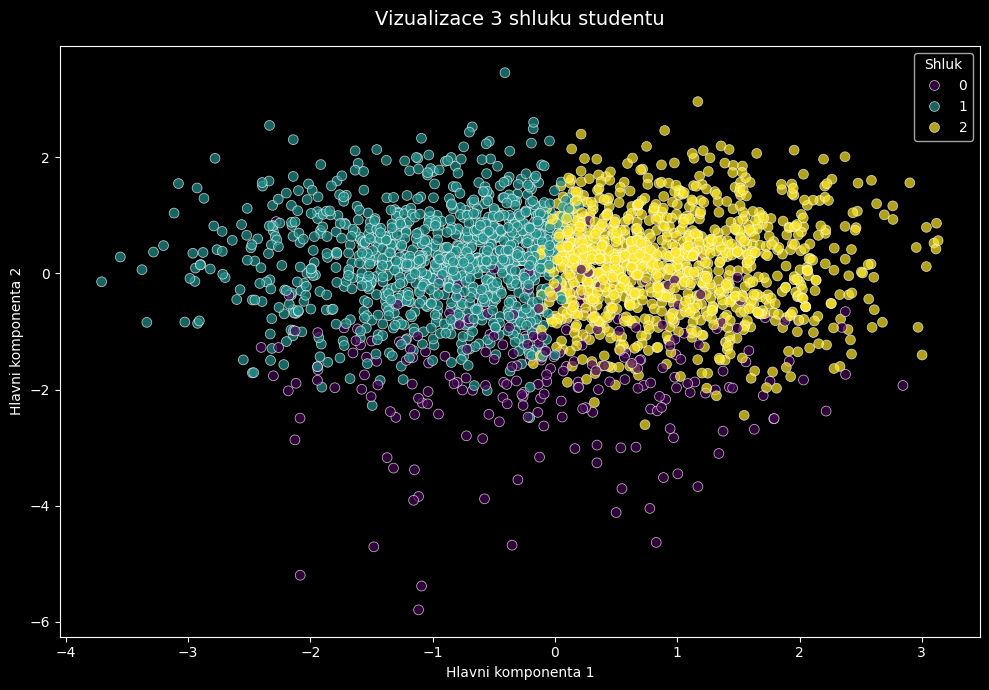

In [29]:
components = pca.transform(X_cluster[cols_for_clustering])

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=components[:, 0], y=components[:, 1],
    hue=X_cluster['Cluster'],
    palette='viridis',
    alpha=0.7,
    s=50
)
plt.title(f'Vizualizace {OPTIMAL_K} shluku studentu', color='white', fontsize=14, pad=15)
plt.xlabel('Hlavni komponenta 1', color='white')
plt.ylabel('Hlavni komponenta 2', color='white')
plt.legend(title='Shluk')
plt.tight_layout()
plt.show()

## Rozlozeni priznaku podle shluku (boxploty)

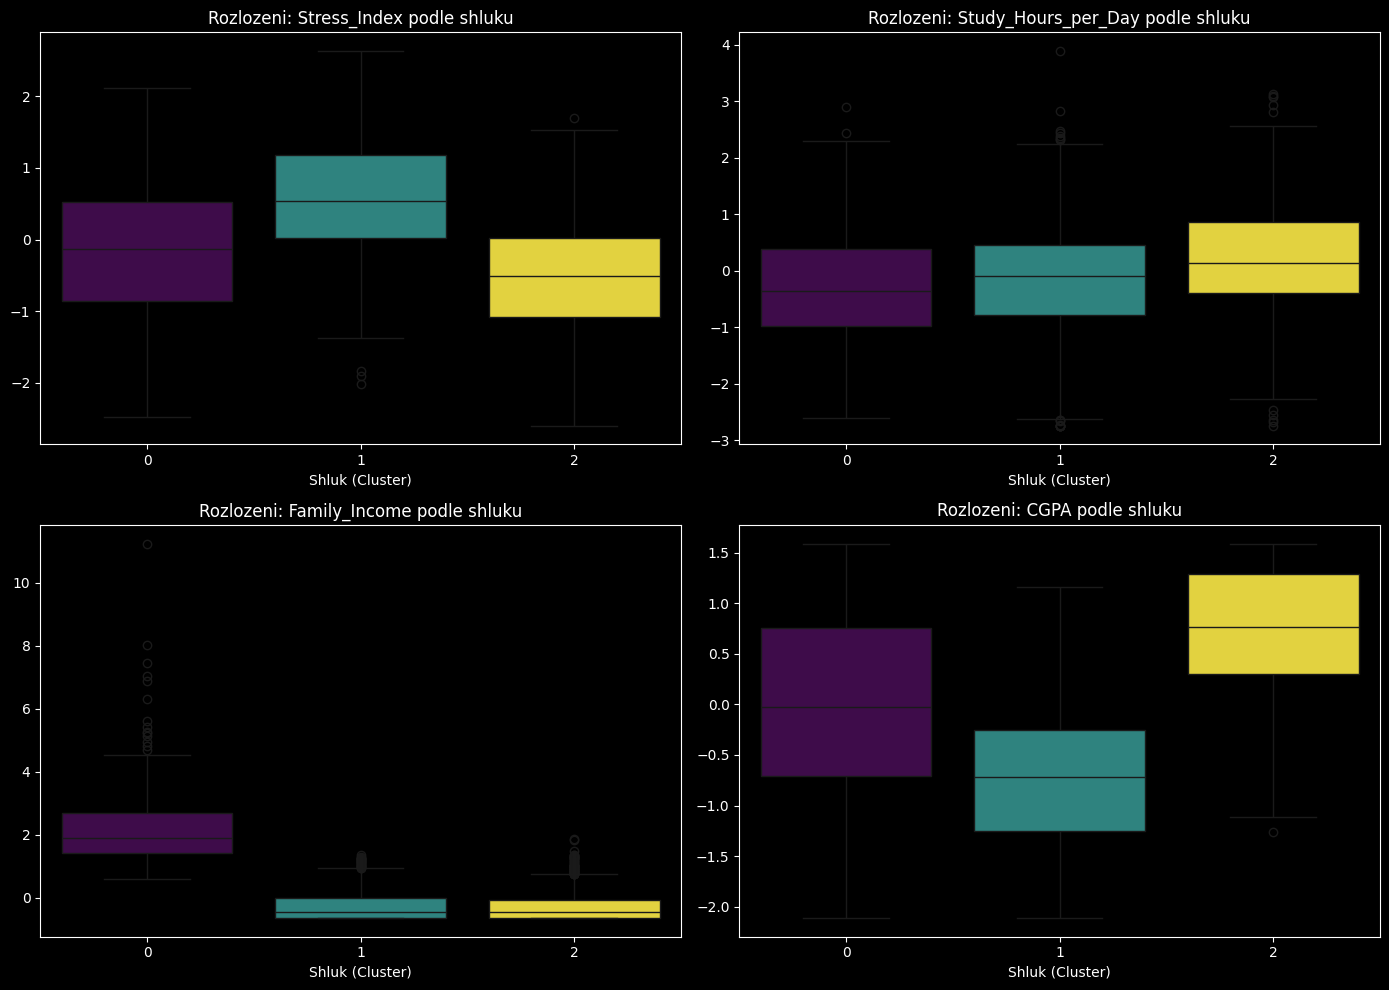

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cols_for_clustering):
    sns.boxplot(
        data=X_cluster, x='Cluster', y=col,
        hue='Cluster', ax=axes[i],
        palette='viridis', legend=False
    )
    axes[i].set_title(f'Rozlozeni: {col} podle shluku', color='white', fontsize=12)
    axes[i].tick_params(colors='white')
    axes[i].set_xlabel('Shluk (Cluster)', color='white')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

## Prumerne hodnoty per shluk (cluster profiles)

In [31]:
cluster_profiles = X_cluster.groupby('Cluster')[cols_for_clustering + ['Dropout']].mean()

print("--- Prumerne hodnoty pro kazdy shluk ---")
print(cluster_profiles.round(3).to_string())

--- Prumerne hodnoty pro kazdy shluk ---
         Stress_Index  Study_Hours_per_Day  Family_Income   CGPA  Dropout
Cluster                                                                  
0              -0.148               -0.270          2.264 -0.034    0.182
1               0.608               -0.162         -0.261 -0.759    0.381
2              -0.558                0.221         -0.271  0.747    0.075


## Dropout rate per shluk

In [32]:
dropout_rate = X_cluster.groupby('Cluster')['Dropout'].agg(['mean', 'count', 'sum'])
dropout_rate.columns = ['Dropout_Rate', 'Celkem_Studentu', 'Pocet_Dropout']
dropout_rate['Dropout_Rate'] = dropout_rate['Dropout_Rate'].map('{:.1%}'.format)

print("--- Dropout rate per shluk ---")
print(dropout_rate.to_string())

--- Dropout rate per shluk ---
        Dropout_Rate  Celkem_Studentu  Pocet_Dropout
Cluster                                             
0              18.2%              258             47
1              38.1%             1084            413
2               7.5%             1113             84


## Agglomerative vs. K-Means — porovnání
Vizualizujeme shluky obou algoritmu ve stejnem 2D PCA prostoru pro primy vizualni srovnani.

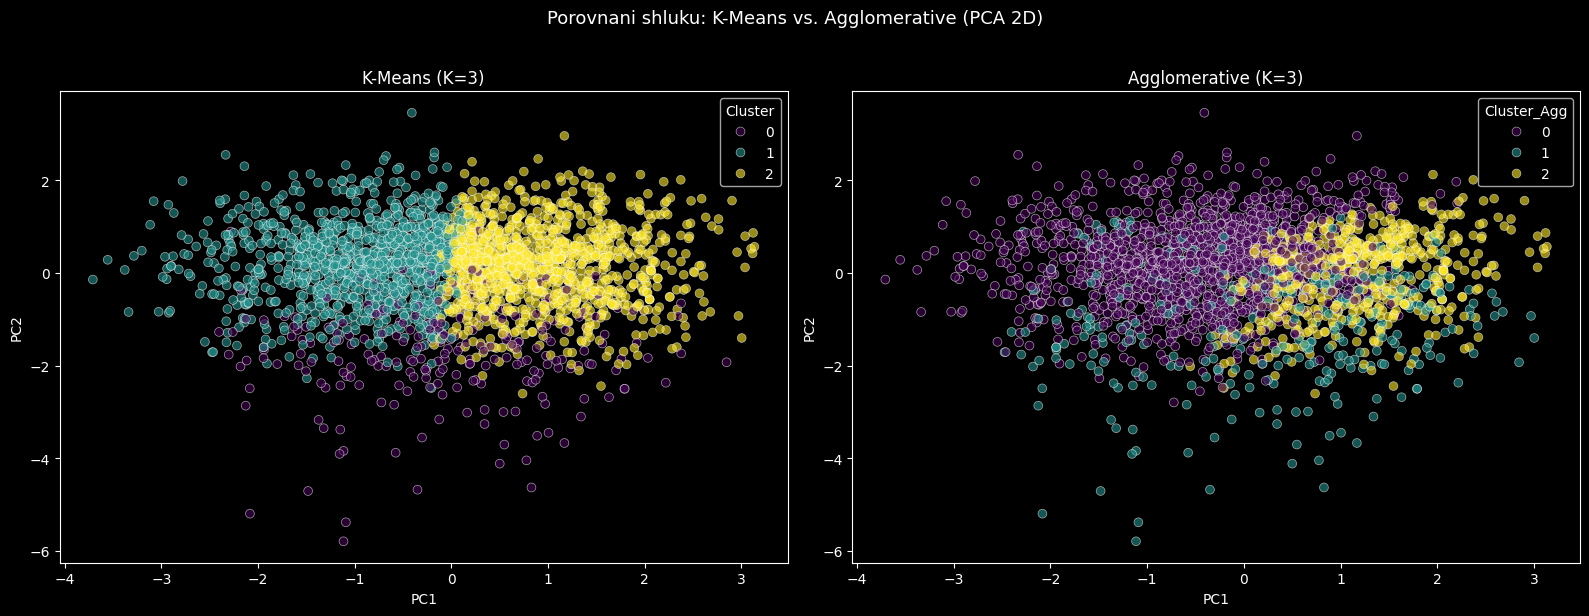


--- Dropout rate: K-Means vs. Agglomerative ---

K-Means:
        Dropout_Rate     N
Cluster                   
0              18.2%   258
1              38.1%  1084
2               7.5%  1113

Agglomerative:
            Dropout_Rate     N
Cluster_Agg                   
0                  30.0%  1512
1                  15.8%   355
2                   5.8%   588


In [33]:
if 'Cluster_Agg' not in X_cluster.columns:
    print("VAROVANI: Cluster_Agg neni v datech — spust znovu 041 s Agglomerative sekcí.")
else:
    components = pca.transform(X_cluster[cols_for_clustering])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, col, title in [
        (axes[0], 'Cluster',     f'K-Means (K={X_cluster["Cluster"].nunique()})'),
        (axes[1], 'Cluster_Agg', f'Agglomerative (K={X_cluster["Cluster_Agg"].nunique()})'),
    ]:
        import seaborn as sns
        sns.scatterplot(
            x=components[:, 0], y=components[:, 1],
            hue=X_cluster[col], palette='viridis', alpha=0.6, s=40, ax=ax
        )
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')

    fig.suptitle('Porovnani shluku: K-Means vs. Agglomerative (PCA 2D)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    # Srovnavaci tabulka dropout rate
    print("\n--- Dropout rate: K-Means vs. Agglomerative ---")
    for col, label in [('Cluster', 'K-Means'), ('Cluster_Agg', 'Agglomerative')]:
        dr = X_cluster.groupby(col)['Dropout'].agg(['mean','count'])
        dr.columns = ['Dropout_Rate', 'N']
        dr['Dropout_Rate'] = dr['Dropout_Rate'].map('{:.1%}'.format)
        print(f"\n{label}:")
        print(dr.to_string())

## Body 10+11+12: Přiřazení vybrané instance do shluku
Prirazujeme studenta z XAI casti (index 17, riziko 85.9 %) do shluku.
- Ktery shluk mu oba algoritmy priradily?
- Jaka je typicka charakteristika tohoto shluku?
- Shoduje se skutecna trida studenta s nejcastejsi tridou v shluku?

In [34]:
import joblib
import pandas as pd
import numpy as np

# Nacteni kontextu z XAI setup
ctx            = joblib.load('../results/xai/xai_context.pkl')
student_index  = ctx['student_index']
X_test_prep    = ctx['X_test_prep']
y_test         = ctx['y_test']

risky_student  = X_test_prep.iloc[student_index]
skutecna_trida = int(y_test.iloc[student_index])

print(f"Vybrana instance: student index {student_index}")
print(f"Skutecna trida: {'Dropout (1)' if skutecna_trida == 1 else 'Dostuduje (0)'}")
print(f"Dostupne clustering featury: {cols_for_clustering}")

# Hodnoty studenta pro clustering featury (surove — pred scalingem)
student_raw_vals = risky_student[cols_for_clustering]
print(f"\nHodnoty instance (surove, pred scalingem):")
print(student_raw_vals.to_string())

# Aplikovat STEJNY scaler jako byl pouzit pri tréninku clusteringu
student_cluster_arr = scaler.transform(student_raw_vals.values.reshape(1, -1))
student_cluster_vals = pd.Series(student_cluster_arr[0], index=cols_for_clustering)
print(f"\nHodnoty instance (po StandardScaler):")
print(student_cluster_vals.round(4).to_string())


Vybrana instance: student index 17
Skutecna trida: Dropout (1)
Dostupne clustering featury: ['Stress_Index', 'Study_Hours_per_Day', 'Family_Income', 'CGPA']

Hodnoty instance (surove, pred scalingem):
Stress_Index           0.277687
Study_Hours_per_Day   -2.100029
Family_Income         -0.083656
CGPA                  -1.611627

Hodnoty instance (po StandardScaler):
Stress_Index           0.3083
Study_Hours_per_Day   -2.0694
Family_Income         -0.0652
CGPA                  -1.5837


/Users/janvrzal/Documents/Uni/Zpracování informací a znalostí/student dropout/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [35]:
# Prirazeni do shluku — K-Means (data jsou jiz normalizovana scalerem)
cluster_kmeans = int(kmeans_final.predict(student_cluster_arr)[0])
print(f"K-Means:       shluk c. {cluster_kmeans}")

# Agglomerative nema predict() — pouzijeme nejblizsi centroid (prumery shluku ze scaled dat)
if 'Cluster_Agg' in X_cluster.columns:
    centroids_agg = X_cluster.groupby('Cluster_Agg')[cols_for_clustering].mean()
    distances     = centroids_agg.apply(
        lambda row: np.linalg.norm(row.values - student_cluster_vals.values), axis=1
    )
    cluster_agg = int(distances.idxmin())
    print(f"Agglomerative: shluk c. {cluster_agg} (nejblizsi centroid, scaled vzdalenost)")
else:
    cluster_agg = None
    print("Agglomerative: data nejsou k dispozici")

# Profil shluku, do ktereho student patri (K-Means)
cluster_profile = X_cluster[X_cluster['Cluster'] == cluster_kmeans]
print(f"\nProfil shluku {cluster_kmeans} ({len(cluster_profile)} studentu):")
print(cluster_profile[cols_for_clustering + ['Dropout']].mean().round(3).to_string())
print(f"  => Dropout rate shluku: {cluster_profile['Dropout'].mean():.1%}")


K-Means:       shluk c. 1
Agglomerative: shluk c. 0 (nejblizsi centroid, scaled vzdalenost)

Profil shluku 1 (1084 studentu):
Stress_Index           0.608
Study_Hours_per_Day   -0.162
Family_Income         -0.261
CGPA                  -0.759
Dropout                0.381
  => Dropout rate shluku: 38.1%


/Users/janvrzal/Documents/Uni/Zpracování informací a znalostí/student dropout/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [36]:
# Bod 12: Shoda skutecne tridy s nejcastejsi tridou v shluku
nejcastejsi_trida_shluku = 1 if cluster_profile['Dropout'].mean() >= 0.5 else 0
shoda = skutecna_trida == nejcastejsi_trida_shluku

print(f"{'=' * 55}")
print(f"  SHODA TRIDY (bod 12)")
print(f"{'=' * 55}")
print(f"  Skutecna trida studenta:        {'Dropout (1)' if skutecna_trida == 1 else 'Dostuduje (0)'}")
print(f"  Nejcastejsi trida v shluku:     {'Dropout (1)' if nejcastejsi_trida_shluku == 1 else 'Dostuduje (0)'}")
print(f"  Shoda:                          {'ANO ✓' if shoda else 'NE ✗'}")

if cluster_agg is not None:
    cluster_profile_agg = X_cluster[X_cluster['Cluster_Agg'] == cluster_agg]
    nejcastejsi_agg = 1 if cluster_profile_agg['Dropout'].mean() >= 0.5 else 0
    shoda_agg = skutecna_trida == nejcastejsi_agg
    print(f"\n  Agglomerative shluk c. {cluster_agg}:")
    print(f"  Dropout rate:                   {cluster_profile_agg['Dropout'].mean():.1%}")
    print(f"  Nejcastejsi trida:              {'Dropout (1)' if nejcastejsi_agg == 1 else 'Dostuduje (0)'}")
    print(f"  Shoda:                          {'ANO ✓' if shoda_agg else 'NE ✗'}")

  SHODA TRIDY (bod 12)
  Skutecna trida studenta:        Dropout (1)
  Nejcastejsi trida v shluku:     Dostuduje (0)
  Shoda:                          NE ✗

  Agglomerative shluk c. 0:
  Dropout rate:                   30.0%
  Nejcastejsi trida:              Dostuduje (0)
  Shoda:                          NE ✗


## Ulozeni cluster profiles

In [37]:
os.makedirs('../results', exist_ok=True)

cluster_profiles.round(4).to_csv('../results/cluster_profiles.csv')
print("  results/cluster_profiles.csv")

  results/cluster_profiles.csv
